<a href="https://colab.research.google.com/github/claudiorafaels/nondeterminism_llm_inference/blob/main/labs_2026_04_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Célula 1
!pip install vllm sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.1/433.1 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3

In [2]:
from huggingface_hub import login
from google.colab import userdata

# Puxa o token secreto que você salvou com o nome "HF_TOKEN"
meu_token = userdata.get('HF_TOKEN')

# Faz o login silenciosamente, sem pedir para você digitar nada
login(token=meu_token)

print("Autenticado com sucesso via Secrets!")

Autenticado com sucesso via Secrets!


In [1]:
# Célula 3: Motor 7B (Forçando variáveis no Sistema Operacional)
%env VLLM_USE_V1=0
%env VLLM_WORKER_MULTIPROC_METHOD=spawn

from vllm import LLM, SamplingParams

print("Iniciando Qwen 7B na GPU A100 (BFloat16 + Deep Layers)...")

try:
    llm = LLM(
        model="Qwen/Qwen2.5-7B-Instruct",
        dtype="bfloat16",
        max_model_len=1024,          # Reduzido preventivamente para evitar estouro de KV Cache
        gpu_memory_utilization=0.8,  # Margem segura para o S.O.
        enforce_eager=False,         # Permite o CUDA Graphs (necessário para o erro)
        distributed_executor_backend="uni"
    )
    print("\n✅ Motor de 7B carregado! VRAM alocada com sucesso.")
except Exception as e:
    print(f"\n❌ Falha: {e}")

env: VLLM_USE_V1=0
env: VLLM_WORKER_MULTIPROC_METHOD=spawn
Iniciando Qwen 7B na GPU A100 (BFloat16 + Deep Layers)...
INFO 04-22 16:46:17 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 1024, 'distributed_executor_backend': 'uni', 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-7B-Instruct'}
WARNING 04-22 16:46:17 [envs.py:1744] Unknown vLLM environment variable detected: VLLM_USE_V1


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

INFO 04-22 16:46:36 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-22 16:46:36 [model.py:1678] Using max model len 1024
INFO 04-22 16:46:36 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-22 16:46:36 [vllm.py:790] Asynchronous scheduling is enabled.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


✅ Motor de 7B carregado! VRAM alocada com sucesso.


In [5]:
# Célula 4 V5: Simulador com Captura de Telemetria (Latência e VRAM)
import time
import torch
import random
import numpy as np
import pandas as pd
from collections import Counter
from vllm import SamplingParams

sampling_params = SamplingParams(temperature=0.0, top_p=1.0, max_tokens=10, seed=42)
prompt_bruto = "Defina o conceito de Transformação Digital em exatamente 6 palavras, nem mais, nem menos."
prompt_formatado = llm.get_tokenizer().apply_chat_template([{"role": "user", "content": prompt_bruto}], tokenize=False, add_generation_prompt=True)

grupos_carga = [int(x) for x in np.linspace(1, 250, 30)]
iteracoes_por_grupo = 20
dados_brutos = []

print(f"Iniciando Teste Escalonado com Telemetria Avançada ({len(grupos_carga)} grupos, 600 inferências totais)...\n")

for carga in grupos_carga:
    print(f"🚀 Testando patamar de {carga} requisições simultâneas...")

    for i in range(iteracoes_por_grupo):
        if carga > 1:
            prompts_ruido = [f"Explain tech in {random.randint(10, 500)} words."] * (carga - 1)
            lote = [prompt_formatado] + [
                llm.get_tokenizer().apply_chat_template([{"role":"user","content":p}], tokenize=False, add_generation_prompt=True)
                for p in prompts_ruido
            ]
        else:
            lote = [prompt_formatado]

        # 1. Reset da medição de memória e início do cronómetro
        torch.cuda.reset_peak_memory_stats()
        start_time = time.time()

        # 2. Execução da Inferência
        out = llm.generate(lote, sampling_params, use_tqdm=False)

        # 3. Paragem do cronómetro e leitura da GPU
        end_time = time.time()
        latencia_segundos = end_time - start_time
        free_mem, total_mem = torch.cuda.mem_get_info()
        vram_gb = (total_mem - free_mem) / (1024 ** 3)

        texto_gerado = out[0].outputs[0].text.strip()

        # Guardamos a linha detalhada
        dados_brutos.append({
            "Carga": carga,
            "Iteracao": i + 1,
            "Resposta": texto_gerado,
            "Latencia_Segundos": latencia_segundos,
            "Pico_VRAM_GB": vram_gb
        })

        # 4. Limpeza da VRAM para não contaminar a próxima iteração
        torch.cuda.empty_cache()

df_bruto = pd.DataFrame(dados_brutos)
print("\n✅ Teste Concluído e Dados Salvos em Memória!")

Iniciando Teste Escalonado com Telemetria Avançada (30 grupos, 600 inferências totais)...

🚀 Testando patamar de 1 requisições simultâneas...
🚀 Testando patamar de 9 requisições simultâneas...
🚀 Testando patamar de 18 requisições simultâneas...
🚀 Testando patamar de 26 requisições simultâneas...
🚀 Testando patamar de 35 requisições simultâneas...
🚀 Testando patamar de 43 requisições simultâneas...
🚀 Testando patamar de 52 requisições simultâneas...
🚀 Testando patamar de 61 requisições simultâneas...
🚀 Testando patamar de 69 requisições simultâneas...
🚀 Testando patamar de 78 requisições simultâneas...
🚀 Testando patamar de 86 requisições simultâneas...
🚀 Testando patamar de 95 requisições simultâneas...
🚀 Testando patamar de 104 requisições simultâneas...
🚀 Testando patamar de 112 requisições simultâneas...
🚀 Testando patamar de 121 requisições simultâneas...
🚀 Testando patamar de 129 requisições simultâneas...
🚀 Testando patamar de 138 requisições simultâneas...
🚀 Testando patamar de 

In [6]:
# Célula 6 V5: Processamento de Telemetria e Drift Semântico
from sentence_transformers import SentenceTransformer, util

print("Carregando modelo de Embeddings (all-MiniLM-L6-v2)...\n")
modelo_emb = SentenceTransformer('all-MiniLM-L6-v2')

# 1. Encontrar a Resposta Dominante (Moda) para cada Carga
resultados_agrupados = []
df_bruto['Similaridade_Cosseno'] = 100.0 # Valor padrão (100% igual)

for carga in df_bruto['Carga'].unique():
    subset = df_bruto[df_bruto['Carga'] == carga]
    contagem = Counter(subset['Resposta'])
    dominante = contagem.most_common(1)[0][0]
    ocorrencias_dominante = contagem.most_common(1)[0][1]
    taxa_erro = ((20 - ocorrencias_dominante) / 20) * 100

    emb_dominante = modelo_emb.encode(dominante, convert_to_tensor=True)

    # Calcular similaridade individual para o Boxplot
    for idx, row in subset.iterrows():
        if row['Resposta'] != dominante:
            emb_var = modelo_emb.encode(row['Resposta'], convert_to_tensor=True)
            sim = util.cos_sim(emb_dominante, emb_var).item() * 100
            df_bruto.at[idx, 'Similaridade_Cosseno'] = sim

    resultados_agrupados.append({
        "Carga": carga,
        "Taxa_Erro_%": taxa_erro,
        "Latencia_Media_s": subset['Latencia_Segundos'].mean(),
        "VRAM_Media_GB": subset['Pico_VRAM_GB'].mean(),
        "Similaridade_Media_%": subset['Similaridade_Cosseno'].mean()
    })

df_agrupado = pd.DataFrame(resultados_agrupados)

correlacao = df_agrupado['Carga'].corr(df_agrupado['Taxa_Erro_%'])
print("="*70)
print(f"RELATÓRIO ESTATÍSTICO GERADO | Pearson (Carga vs Erro): {correlacao:.4f}")
print("="*70)

Carregando modelo de Embeddings (all-MiniLM-L6-v2)...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RELATÓRIO ESTATÍSTICO GERADO | Pearson (Carga vs Erro): 0.2296


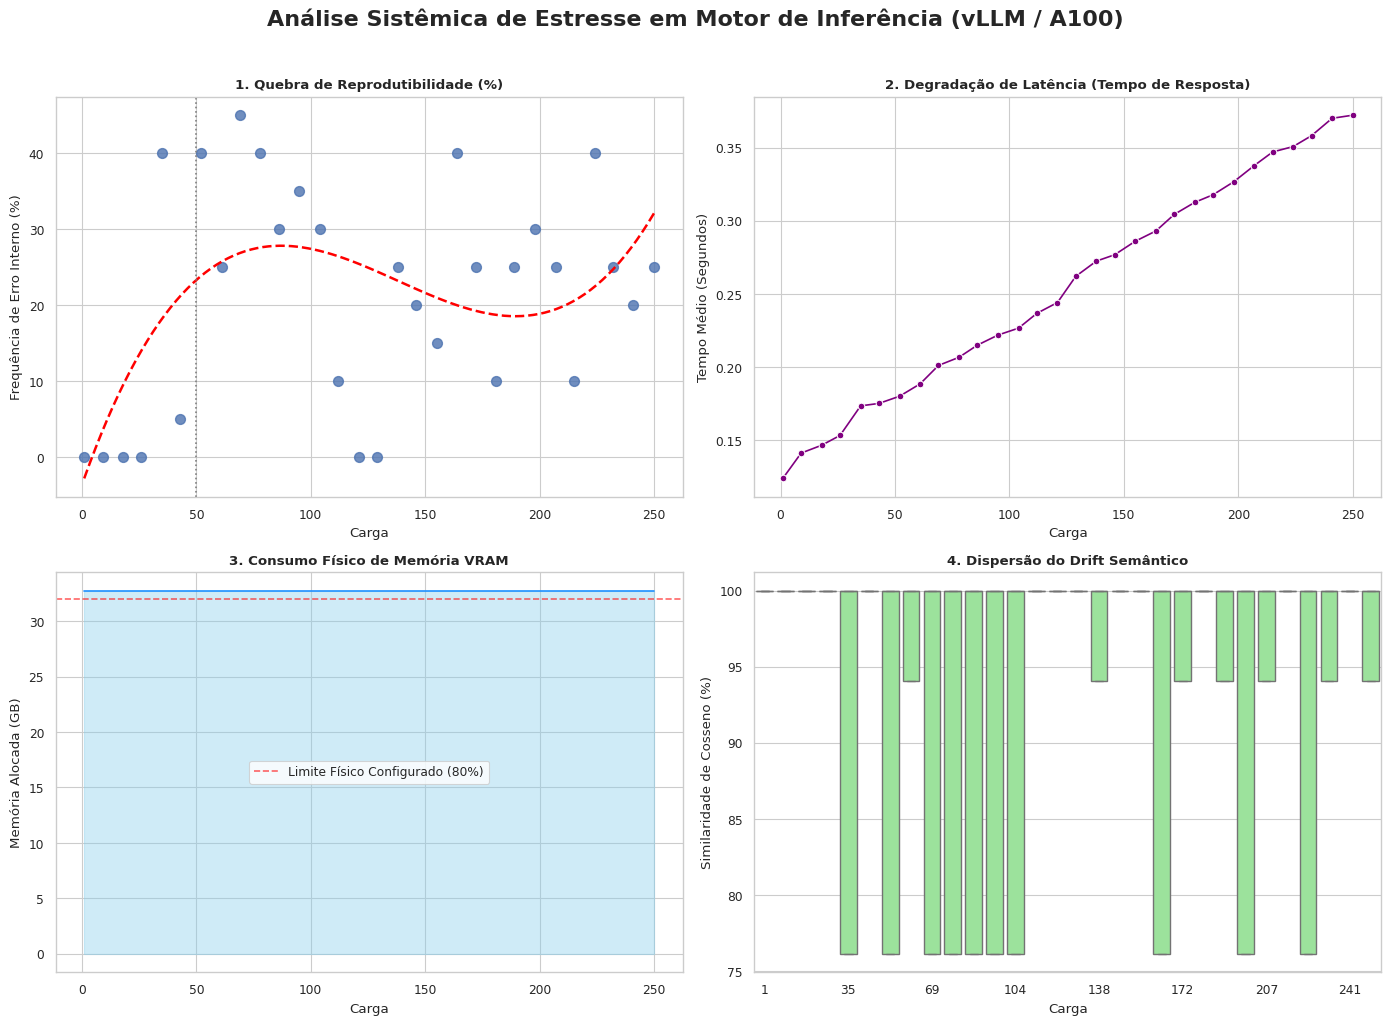

In [9]:
# Célula 7 V5: Painel de Múltiplos Resultados
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise Sistêmica de Estresse em Motor de Inferência (vLLM / A100)', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Erro de Determinismo (Original melhorado)
sns.regplot(ax=axes[0, 0], data=df_agrupado, x='Carga', y='Taxa_Erro_%',
            order=3, ci=None, scatter_kws={'s': 50}, line_kws={'color': 'red', 'linestyle': '--'})
axes[0, 0].axvline(x=50, color='gray', linestyle=':', label='Ponto de Ruptura Estimado')
axes[0, 0].set_title('1. Quebra de Reprodutibilidade (%)', fontweight='bold')
axes[0, 0].set_ylabel('Frequência de Erro Interno (%)')

# Gráfico 2: Desempenho (Latência)
sns.lineplot(ax=axes[0, 1], data=df_agrupado, x='Carga', y='Latencia_Media_s', color='purple', marker='o')
axes[0, 1].set_title('2. Degradação de Latência (Tempo de Resposta)', fontweight='bold')
axes[0, 1].set_ylabel('Tempo Médio (Segundos)')

# Gráfico 3: Consumo Físico (VRAM)
axes[1, 0].fill_between(df_agrupado['Carga'], df_agrupado['VRAM_Media_GB'], color="skyblue", alpha=0.4)
sns.lineplot(ax=axes[1, 0], data=df_agrupado, x='Carga', y='VRAM_Media_GB', color='dodgerblue')
axes[1, 0].axhline(y=32, color='red', linestyle='--', alpha=0.6, label='Limite Físico Configurado (80%)')
axes[1, 0].set_title('3. Consumo Físico de Memória VRAM', fontweight='bold')
axes[1, 0].set_ylabel('Memória Alocada (GB)')
axes[1, 0].legend()

# Gráfico 4: Dispersão do Erro (Boxplot de Drift)
sns.boxplot(ax=axes[1, 1], data=df_bruto, x='Carga', y='Similaridade_Cosseno', color='lightgreen', showfliers=False)
# Para não poluir o eixo X do boxplot com 30 números colados, mostramos apenas alguns
for ind, label in enumerate(axes[1, 1].get_xticklabels()):
    if ind % 4 == 0:  label.set_visible(True)
    else: label.set_visible(False)
axes[1, 1].set_title('4. Dispersão do Drift Semântico', fontweight='bold')
axes[1, 1].set_ylabel('Similaridade de Cosseno (%)')

plt.tight_layout()
plt.savefig('Painel_Resultados_TCC_Alta_Resolucao.png', dpi=300, bbox_inches='tight')
plt.show()

# Exportar a Tabela Resumo para o Excel
df_agrupado.to_excel('Tabela_Estatistica_Completa_TCC.xlsx', index=False)